In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import infercnvpy as cnv
import matplotlib.pyplot as plt

In [4]:
sc.settings.verbosity = 2
sc.settings.set_figure_params(frameon=False)
sc.settings._vector_friendly = False
plt.rcParams["axes.grid"] = False

In [5]:
# set working directory
project_dir = os.path.expanduser("~/BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# set data directory
data_dir = working_dir

# set figure directory
figure_dir = working_dir + "figures/"

# processed data directory
data_dir = working_dir + "data/"

In [6]:
adata_full = sc.read_h5ad(data_dir + "adata_full_harmony_integration.h5ad")

In [7]:
adata_full.layers["counts"] = adata_full.X.copy()

In [8]:
adata_full.obs["patient"] = adata_full.obs["patient"].str.replace("Patient.", "Patient_", regex=False)

In [9]:
cnv.io.genomic_position_from_biomart(adata_full, biomart_gene_id="hgnc_symbol")

In [10]:
adata = adata_full.copy()

In [11]:
adata = adata[adata.obs["cellclass"].isin(["EPI"])].copy()

In [12]:
adata.obs["celltype"] = np.where(adata.obs["disease"] == "normal", "Normal", adata.obs["celltype"])
adata.obs["celltype"] = adata.obs["celltype"].astype("category")

In [13]:
adata.obs["celltype"] = adata.obs["celltype"].cat.remove_unused_categories()

In [14]:
adata.X = adata.layers["counts"].copy()
sc.pp.filter_genes(adata, min_cells=20)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

filtered out 508 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:06)


In [15]:
cnv.tl.infercnv(
    adata,
    reference_key="celltype",
    reference_cat="Normal",
    n_jobs=32,
    exclude_chromosomes=["chrX", "chrY", "chrMT", "chrGL000194.1"],
    calculate_gene_values=False,
)

  0%|          | 0/19 [00:00<?, ?it/s]

In [17]:
adata = adata[~adata.obs["celltype"].isin(["Normal"])].copy()
adata.obs["celltype"] = adata.obs["celltype"].cat.remove_unused_categories()

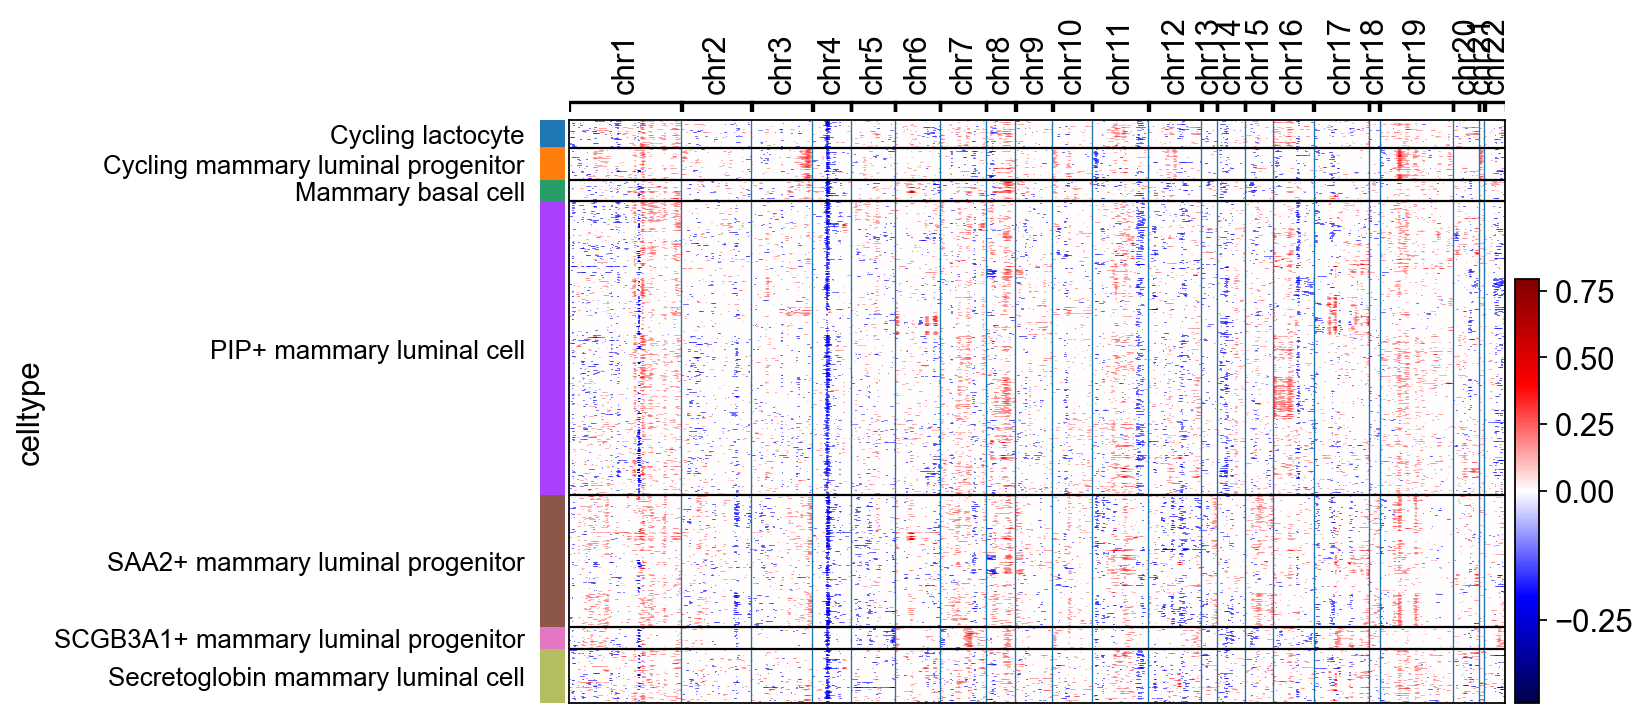

In [18]:
cnv.pl.chromosome_heatmap(
    adata,
    groupby="celltype",
    figsize=(8, 5),
    cmap="seismic",
    save="_infercnv_celltype.pdf",
)

In [19]:
cnv.tl.pca(adata)
cnv.pp.neighbors(adata)

computing PCA
    with n_comps=50
    finished (0:00:09)
computing neighbors
    finished (0:00:50)


In [20]:
cnv.tl.leiden(adata, resolution=0.015, key_added="subclone")

running Leiden clustering
    finished (0:00:32)


In [21]:
adata.uns.pop("dendrogram_subclone", None)
adata.uns.pop("subclone_colors", None)

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_subclone']`
categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


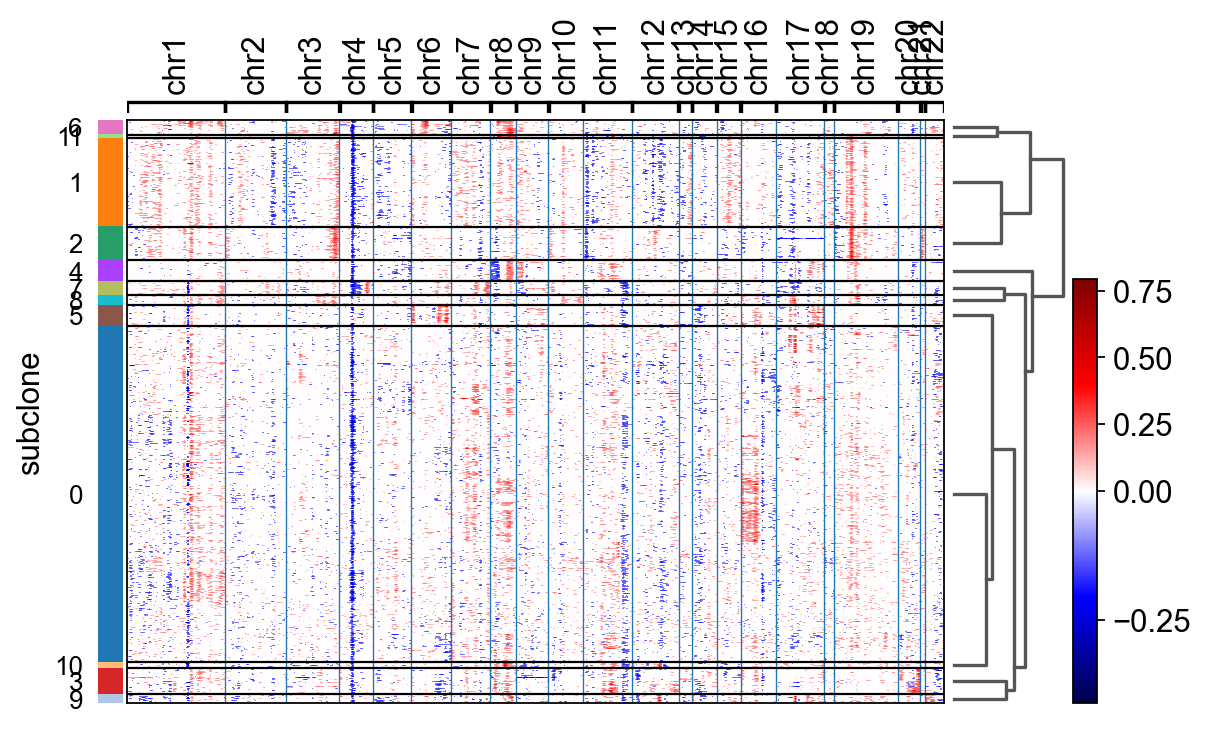

In [22]:
sc.tl.dendrogram(adata, groupby="subclone")
cnv.pl.chromosome_heatmap(
    adata,
    groupby="subclone",
    dendrogram=True,
    figsize=(8, 5),
    cmap="seismic",
    save="_infercnv_subclone.pdf",
)

In [24]:
group_colors = {
    "G0-arrested": "#6A5ACD",
    "Slow-cycling": "#8c8c8c",
    "Fast-cycling": "#2FBF71",
}
adata.uns["cycling_state_oren_colors"] = [
    group_colors[k] for k in adata.obs["cycling_state_oren"].cat.categories
]

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_cycling_state_oren']`
categories: Fast-cycling, G0-arrested, Slow-cycling
var_group_labels: chr1, chr2, chr3, etc.


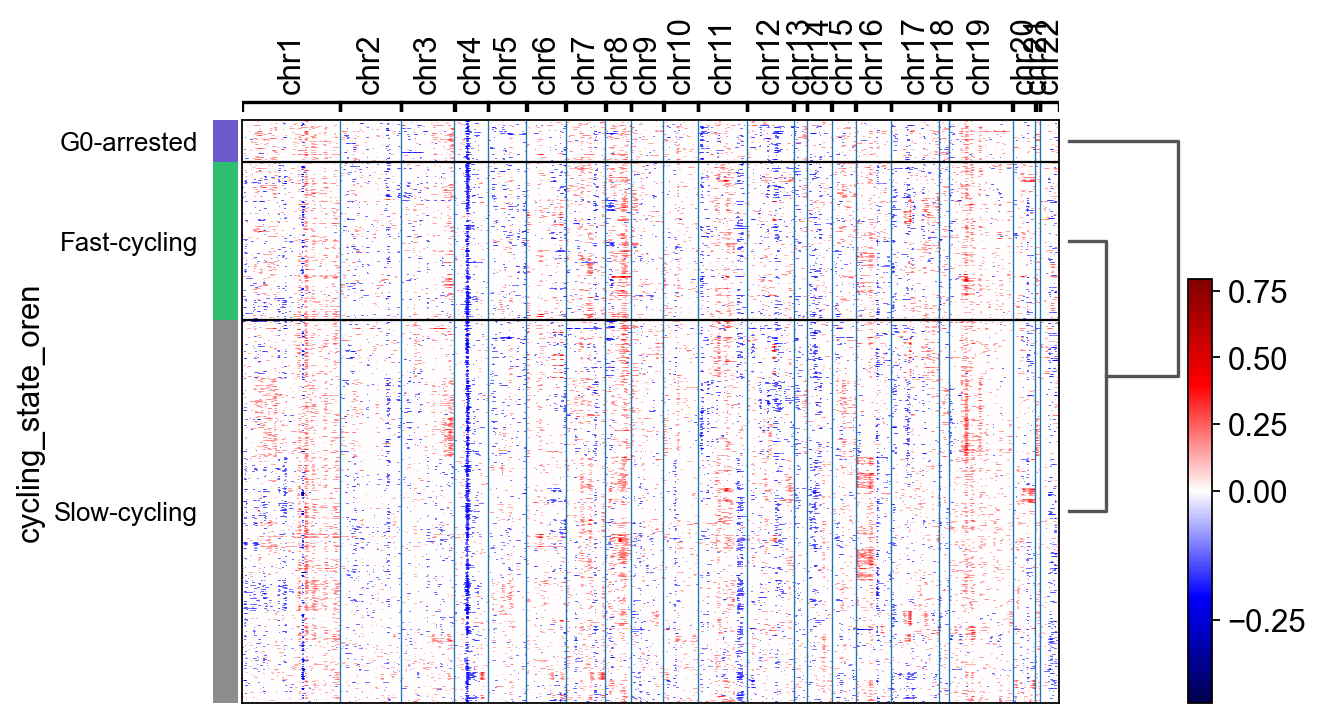

In [25]:
sc.tl.dendrogram(adata, groupby="cycling_state_oren")
cnv.pl.chromosome_heatmap(
    adata,
    groupby="cycling_state_oren",
    dendrogram=True,
    figsize=(8, 5),
    cmap="seismic",
    save="_infercnv_cycling_state.pdf",
)

In [26]:
cnv.tl.ithcna(adata, groupby="cycling_state_oren")

In [33]:
def lineplot_ithcna_per_patient(
    adata,
    group_column: str,
    patient_column: str = "patient",
    order=None,
    palette=None,
    figsize=(3, 4),
    xlabel=None,
    ylabel=None,
    title=None,
    save_path=None,
    ax=None,
    return_stats=False,
):
    """
    Connected line plot of ITH-CNA (z-scored within patient) across cycling states.
    Each patient is drawn as a faint line; the median per category is overlaid solid.
    Pairwise Mann-Whitney U p-values are annotated above.
    """
    records = []
    for patient in adata.obs[patient_column].unique():
        adata_pt = adata[adata.obs[patient_column] == patient].copy()
        adata_pt.obs[group_column] = (
            adata_pt.obs[group_column]
            .astype("category")
            .cat.remove_unused_categories()
        )
        group_counts = adata_pt.obs[group_column].value_counts()
        valid_groups = group_counts[group_counts > 1].index
        adata_pt = adata_pt[adata_pt.obs[group_column].isin(valid_groups)].copy()
        adata_pt.obs[group_column] = adata_pt.obs[group_column].cat.remove_unused_categories()
        if adata_pt.obs[group_column].nunique() < 2:
            continue
        cnv.tl.ithcna(adata_pt, groupby=group_column)
        means = (
            adata_pt.obs.groupby(group_column)["ithcna"]
            .mean()
            .reset_index()
            .rename(columns={"ithcna": "ithcna_mean"})
            .assign(**{patient_column: patient})
        )
        means["ithcna_z"] = zscore(means["ithcna_mean"])
        records.append(means)

    obs = pd.concat(records, ignore_index=True)

    if order is None:
        order = sorted(obs[group_column].dropna().unique())
    if palette is None:
        palette = {k: f"C{i}" for i, k in enumerate(order)}

    x_pos = {g: i for i, g in enumerate(order)}

    show_fig = ax is None
    if show_fig:
        fig, ax = plt.subplots(figsize=figsize)

    # --- per-patient faint lines ---
    for patient, grp in obs.groupby(patient_column):
        grp_sorted = grp.set_index(group_column).reindex(order).dropna(subset=["ithcna_z"])
        if len(grp_sorted) < 2:
            continue
        xs = [x_pos[g] for g in grp_sorted.index]
        ys = grp_sorted["ithcna_z"].values
        ax.plot(xs, ys, color="grey", linewidth=0.8, alpha=0.25, zorder=1)
        for x, y, g in zip(xs, ys, grp_sorted.index):
            ax.scatter(x, y, color=palette.get(g, "grey"), s=18, alpha=0.3, zorder=2, linewidths=0)

    # --- median line per category (solid) ---
    medians = obs.groupby(group_column)["ithcna_z"].median().reindex(order)
    xs_med = [x_pos[g] for g in medians.index if not pd.isna(medians[g])]
    ys_med = [medians[g] for g in medians.index if not pd.isna(medians[g])]
    ax.plot(xs_med, ys_med, color="black", linewidth=2.0, zorder=4)
    for x, y, g in zip(xs_med, ys_med, [g for g in medians.index if not pd.isna(medians[g])]):
        ax.scatter(x, y, color=palette.get(g, "black"), s=60, zorder=5, linewidths=0.8, edgecolors="black")

    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, fontsize=10)
    sns.despine(ax=ax)

    # --- pairwise Mann-Whitney U ---
    stat_dict = {}
    ymax = obs["ithcna_z"].max()
    ymin = obs["ithcna_z"].min()
    y_range = ymax - ymin
    for idx, (g1, g2) in enumerate(combinations(order, 2)):
        v1 = obs.loc[obs[group_column] == g1, "ithcna_z"]
        v2 = obs.loc[obs[group_column] == g2, "ithcna_z"]
        if len(v1) < 2 or len(v2) < 2:
            continue
        stat, p = mannwhitneyu(v1, v2, alternative="two-sided")
        stat_dict[(g1, g2)] = (stat, p)
        x1, x2 = x_pos[g1], x_pos[g2]
        y = ymax + y_range * (0.12 + 0.18 * idx)
        ax.plot([x1, x2], [y, y], color="black", linewidth=1)
        stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        ax.text((x1 + x2) / 2, y + y_range * 0.03, stars, ha="center", fontsize=9)

    ax.set_xlabel(xlabel or "", fontsize=12)
    ax.set_ylabel(ylabel or "ITH-CNA (z-score within patient)", fontsize=12)
    if title:
        ax.set_title(title, fontsize=13)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(False)
    ax.set_box_aspect(1)
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    if show_fig:
        plt.tight_layout()
        plt.show()

    if return_stats:
        return stat_dict


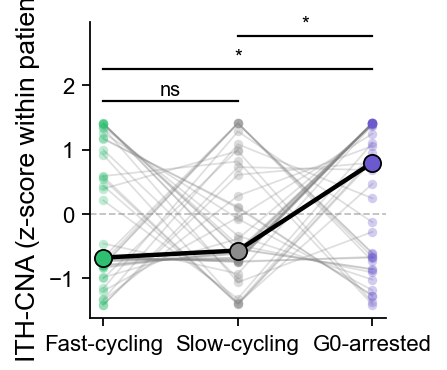

In [34]:
lineplot_ithcna_per_patient(
    adata,
    group_column="cycling_state_oren",
    palette={
        "G0-arrested": "#6A5ACD",
        "Slow-cycling": "#8c8c8c",
        "Fast-cycling": "#2FBF71",
    },
    order=["Fast-cycling", "Slow-cycling", "G0-arrested"],
    save_path=figure_dir + "lineplot_ithcna_per_patient.pdf",
)

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import mannwhitneyu


def plot_violin_with_pvalue(
    adata,
    group_column: str,
    score_column: str,
    order=None,
    palette=None,
    figsize=(3, 3),
    xlabel=None,
    ylabel=None,
    title=None,
    log_y=False,
    save_path=None,
    ax=None,
    return_stats=False,
):
    """
    Generalised violin plot with optional Mann–Whitney U test annotation
    including pairwise comparison lines and p-value asterisks.

    Parameters:
    - adata: AnnData object
    - group_column: Categorical column in adata.obs
    - score_column: Numerical column in adata.obs
    - order: List/tuple of group order (default: sorted categories)
    - palette: Optional dict of colours for each group
    - figsize: Figure size if ax is not provided
    - xlabel, ylabel: Optional axis labels
    - title: Optional title
    - log_y: Whether to use log scale on y-axis
    - save_path: If provided, saves figure to this path
    - ax: Optional matplotlib axis
    - return_stats: If True, returns dictionary of pairwise stats

    Returns:
    - dict of {(group1, group2): (stat, p)} if return_stats is True
    """

    obs = adata.obs[[group_column, score_column]].dropna()
    groups = obs[group_column].unique()

    if order is None:
        order = sorted(groups)

    if palette is None:
        palette = {k: f"C{i}" for i, k in enumerate(order)}

    show_fig = ax is None
    if show_fig:
        fig, ax = plt.subplots(figsize=figsize)

    ax.axhline(0, color="grey", linestyle="--", linewidth=0.5, alpha=0.5)

    sns.violinplot(
        data=obs, x=group_column, y=score_column, palette=palette, order=order, ax=ax
    )
    sns.despine(ax=ax)

    # Pairwise Mann–Whitney U tests
    stat_dict = {}
    for idx, (g1, g2) in enumerate(combinations(order, 2)):
        group1 = obs.loc[obs[group_column] == g1, score_column]
        group2 = obs.loc[obs[group_column] == g2, score_column]
        stat, p = mannwhitneyu(group1, group2, alternative="two-sided")
        stat_dict[(g1, g2)] = (stat, p)

        # Draw line and annotate p-value
        y_max = obs[score_column].max()
        y_offset = 0.1 * (idx + 1) * y_max
        x1, x2 = order.index(g1), order.index(g2)
        ax.plot([x1, x2], [y_max + y_offset] * 2, color="black", linewidth=1)
        if p < 0.05:
            if p < 0.001:
                text = "***"
            elif p < 0.01:
                text = "**"
            else:
                text = "*"
            ax.text(
                (x1 + x2) / 2, y_max + y_offset * 1.05, text, ha="center", fontsize=10
            )
        else:
            ax.text(
                (x1 + x2) / 2, y_max + y_offset * 1.05, "ns", ha="center", fontsize=10
            )

    # Axis styling
    ax.set_xlabel(xlabel or group_column, fontsize=12)
    ax.set_ylabel(ylabel or score_column, fontsize=12)
    if title:
        ax.set_title(title, fontsize=13)
    if log_y:
        ax.set_yscale("log")
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(False)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    if show_fig:
        plt.tight_layout()
        plt.show()

    if return_stats:
        return stat_dict


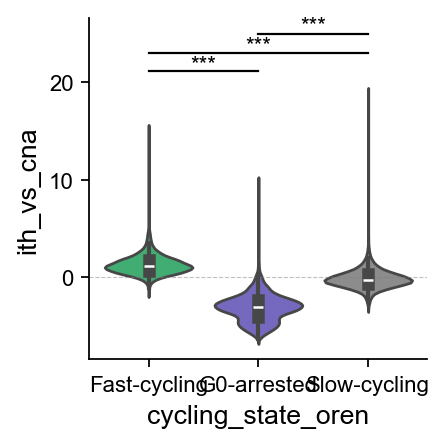

In [32]:
# Ensure both columns are numeric
adata.obs["cna_burden"] = np.abs(adata.obsm["X_cnv"]).sum(axis=1)
adata.obs["ithcna_norm_numeric"] = pd.to_numeric(adata.obs["ithcna"], errors="coerce")
adata.obs["cna_burden_numeric"] = pd.to_numeric(adata.obs["cna_burden"], errors="coerce")

ith_z = (adata.obs["ithcna_norm_numeric"] - adata.obs["ithcna_norm_numeric"].mean()) / adata.obs["ithcna_norm_numeric"].std()
cna_z = (adata.obs["cna_burden_numeric"] - adata.obs["cna_burden_numeric"].mean()) / adata.obs["cna_burden_numeric"].std()
adata.obs["ith_vs_cna"] = cna_z - ith_z

plot_violin_with_pvalue(
    adata,
    group_column="cycling_state_oren",
    score_column="ith_vs_cna",
    palette={
        "G0-arrested": "#6A5ACD",
        "Slow-cycling": "#8c8c8c",
        "Fast-cycling": "#2FBF71",
    },
    save_path=figure_dir + "violin_ith_cna_cycling_state.pdf",
)